# Member 1 — Results & Status Specialist
**Files:** `results.csv`, `status.csv`, `constructor_results.csv` &nbsp;|&nbsp; **Owner:** Hisham

**Scope of this section**
1. Audit the raw tables (before-cleaning EDA)
2. Replace the `\N` sentinels (and any *hidden* sentinels) and apply semantic typing, especially fastest-lap time/speed
3. Verify primary keys and foreign keys
4. Group all 139 `status` values into mechanical / non-mechanical for Data-Engineering Question 3
5. Re-audit (after-cleaning EDA) and state which columns are **post-race (leakage)**

Raw CSVs are never modified — everything below works on copies and writes new files to `OUT_DIR`.

## 0. Setup

In [7]:
import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 200, "display.max_columns", 50, "display.max_rows", 200)

# Works on Kaggle, locally, or in this workspace -- first existing folder wins.
CANDIDATES = ["/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020",
              "/kaggle/input/f1-dataset", "/mnt/user-data/uploads", "./data", "."]
DATA_DIR = next(p for p in CANDIDATES if os.path.exists(os.path.join(p, "results.csv")))
OUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "/mnt/user-data/outputs"
os.makedirs(OUT_DIR, exist_ok=True)
SENTINEL = r"\N"
print("DATA_DIR =", DATA_DIR, "| OUT_DIR =", OUT_DIR)

DATA_DIR = /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020 | OUT_DIR = /kaggle/working


## 1. Raw audit (BEFORE cleaning)
We read every column as **string** so nothing is silently coerced, then count the literal `\N` sentinel per column.

In [8]:
raw = {n: pd.read_csv(f"{DATA_DIR}/{n}.csv", dtype=str, keep_default_na=False)
       for n in ["results", "status", "constructor_results", "races", "drivers", "constructors"]}
for n, d in raw.items():
    print(f"{n:22s} rows={len(d):6d} cols={d.shape[1]}")

def sentinel_report(df):
    n = (df == SENTINEL).sum()
    return pd.DataFrame({"n_sentinel": n, "pct": (100 * n / len(df)).round(2)})

rep_res = sentinel_report(raw["results"]); rep_cr = sentinel_report(raw["constructor_results"])
print("\nresults.csv"); display(rep_res[rep_res.n_sentinel > 0])
print("constructor_results.csv"); display(rep_cr[rep_cr.n_sentinel > 0])
print("status.csv sentinels:", int((raw["status"] == SENTINEL).sum().sum()))

results                rows= 26759 cols=18
status                 rows=   139 cols=2
constructor_results    rows= 12625 cols=5
races                  rows=  1125 cols=18
drivers                rows=   861 cols=9
constructors           rows=   212 cols=5

results.csv


,n_sentinel,pct
number,6,0.02
position,10953,40.93
time,19079,71.30
milliseconds,19079,71.30
fastestLap,18507,69.16
rank,18249,68.20
fastestLapTime,18507,69.16
fastestLapSpeed,18507,69.16


constructor_results.csv


,n_sentinel,pct
status,12608,99.87


status.csv sentinels: 0


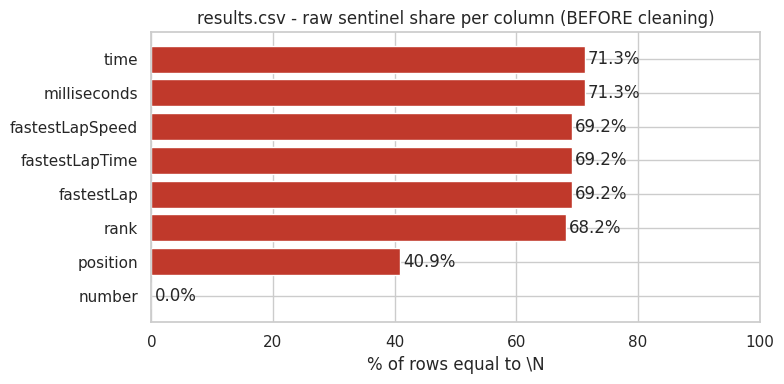

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
r = rep_res[rep_res.n_sentinel > 0].sort_values("pct")
ax.barh(r.index, r.pct, color="#c0392b")
for y, v in enumerate(r.pct): ax.text(v + .5, y, f"{v:.1f}%", va="center")
ax.set_xlabel("% of rows equal to \\N"); ax.set_title("results.csv - raw sentinel share per column (BEFORE cleaning)")
ax.set_xlim(0, 100); plt.tight_layout(); plt.show()

**Reading the plot.** `position` is `\N` for every driver who was not classified (retired early, DSQ, DNQ...), which is why the target uses `positionOrder` instead.
`time`/`milliseconds` are missing for everyone who did not finish on the lead lap (+ early years), and the fastest-lap block (`fastestLap`, `fastestLapTime`, `fastestLapSpeed`) is missing for ~70% of rows.
Section 3 checks whether that is *structural* (the data was never recorded in that era) rather than random.

## 2. Sentinel cleaning (on a copy)

In [10]:
res = raw["results"].copy()
res = res.replace(SENTINEL, np.nan)            # the sentinel -> real missing value
assert not (res == SENTINEL).any().any()

# --- numeric typing (nullable Int64 so ids/positions stay integers even with NaN)
int_cols = ["resultId","raceId","driverId","constructorId","number","grid","position",
            "positionOrder","laps","milliseconds","fastestLap","rank","statusId"]
for c in int_cols: res[c] = pd.to_numeric(res[c]).astype("Int64")
for c in ["points", "fastestLapSpeed"]: res[c] = pd.to_numeric(res[c]).astype("float64")
res.dtypes

resultId             Int64
raceId               Int64
driverId             Int64
constructorId        Int64
number               Int64
grid                 Int64
position             Int64
positionText        object
positionOrder        Int64
points             float64
laps                 Int64
time                object
milliseconds         Int64
fastestLap           Int64
rank                 Int64
fastestLapTime      object
fastestLapSpeed    float64
statusId             Int64
dtype: object

### 2.1 Hidden sentinels (not written as `\N`)
A literal-`\N` search is not enough. Two values behave like sentinels:
* `rank == 0` while `fastestLapTime` is missing → "no fastest lap recorded", not "ranked 0th".
* `grid == 0` → either a **pit-lane start** or **did not qualify / no grid slot** (checked in 2.2).

In [11]:
ghost_rank = res["rank"].eq(0) & res["fastestLapTime"].isna()
print("rank==0 with no fastest-lap time:", int(ghost_rank.sum()), "of", int(res["rank"].eq(0).sum()), "rank==0 rows")
print("rank range among rows with a time:", res.loc[res.fastestLapTime.notna(), "rank"].min(), "-", res.loc[res.fastestLapTime.notna(), "rank"].max())
res.loc[res["rank"].eq(0), "rank"] = pd.NA     # 0 is not a valid rank (valid ranks start at 1)
print("rank==0 left:", int(res["rank"].eq(0).sum()))

rank==0 with no fastest-lap time: 258 of 258 rank==0 rows
rank range among rows with a time: 1 - 24
rank==0 left: 0


### 2.2 What does `grid == 0` mean? (needed before anyone uses `grid` as a feature)

In [12]:
status = raw["status"].copy(); status["statusId"] = status["statusId"].astype(int)
tmp = res.merge(status, on="statusId", how="left")
g0 = tmp[tmp.grid == 0]
print("grid==0 rows:", len(g0), f"({100*len(g0)/len(tmp):.1f}% of rows)")
display(g0.status.value_counts().head(8).to_frame("n"))

grid==0 rows: 1638 (6.1% of rows)


,n
status,
Did not qualify,1013
Did not prequalify,331
Withdrew,164
+1 Lap,27
Finished,22
Accident,20
Injury,8
+2 Laps,7


Most `grid == 0` rows are `Did not qualify` / `Did not prequalify` / `Withdrew` (**never started**), with a smaller number of true pit-lane starts.
So `0` is a *code*, not a position. For the modeling table the team must decide whether DNQ/DNPQ rows are in scope (they never had a prediction to make). **Flag for the group discussion**; I expose `grid_is_zero` in the output so the decision is a one-line filter.

## 3. Semantic typing — fastest lap time, speed, race time

| Raw | Format | New column |
|---|---|---|
| `fastestLapTime` | `m:ss.mmm` string | `fastest_lap_s` (float seconds) |
| `fastestLapSpeed` | km/h string | already float -> `fastest_lap_kmh` |
| `milliseconds` | total race time (all finishers on lead lap *and* lapped finishers) | `race_time_s` |
| `time` | winner: absolute `h:mm:ss.mmm`; others: gap `+s.mmm` / `+m:ss.m` | `gap_to_winner_s` |

In [13]:
def to_seconds(s):
    """'1:27.452' / '1:16:24.572' / '+1:29.6' / '+5.28' -> float seconds (NaN if missing/unparseable)."""
    if pd.isna(s): return np.nan
    s = str(s).lstrip("+")
    try:
        parts = [float(p) for p in s.split(":")]
    except ValueError:
        return np.nan
    out = 0.0
    for p in parts: out = out * 60 + p
    return out

res["fastest_lap_s"]   = res["fastestLapTime"].map(to_seconds)
res["fastest_lap_kmh"] = res["fastestLapSpeed"]
res["race_time_s"]     = res["milliseconds"].astype("float64") / 1000
is_gap = res["time"].str.startswith("+", na=False)
is_winner = res["position"].eq(1).fillna(False).astype(bool) & res["time"].notna() & ~is_gap
res["gap_to_winner_s"] = np.where(is_gap, res["time"].map(to_seconds), np.where(is_winner, 0.0, np.nan))

# parse-failure audit: every non-null raw string that should be numeric must have produced a number
print("parse failures fastestLapTime:", int((res.fastestLapTime.notna() & res.fastest_lap_s.isna()).sum()))
print("parse failures time (gap strings):", int((is_gap & res.gap_to_winner_s.isna()).sum()))
res[["fastestLapTime","fastest_lap_s","fastestLapSpeed","time","gap_to_winner_s","race_time_s"]].dropna(subset=["fastest_lap_s"]).sample(6, random_state=3)

parse failures fastestLapTime: 0
parse failures time (gap strings): 0


,fastestLapTime,fastest_lap_s,fastestLapSpeed,time,gap_to_winner_s,race_time_s
26457,1:26.012,86.012,182.528,NaN,NaN,NaN
21484,1:26.061,86.061,183.260,NaN,NaN,NaN
24265,1:46.009,106.009,203.858,+1:43.816,103.816,5616.758
24141,1:18.741,78.741,196.776,NaN,NaN,NaN
25448,1:22.731,82.731,229.669,+1:16.221,76.221,5342.769
1684,1:11.255,71.255,211.791,NaN,NaN,NaN


### 3.1 Plausibility checks (typing is only done when the numbers make sense)

       fastest_lap_s  fastest_lap_kmh
count        8252.00          8252.00
mean           90.83           204.12
std            12.34            21.38
min            55.40            89.54
25%            80.85           193.32
50%            90.27           204.89
75%            99.48           217.32
max           202.30           257.32

lap-length coefficient of variation across circuits (median %): 0.0


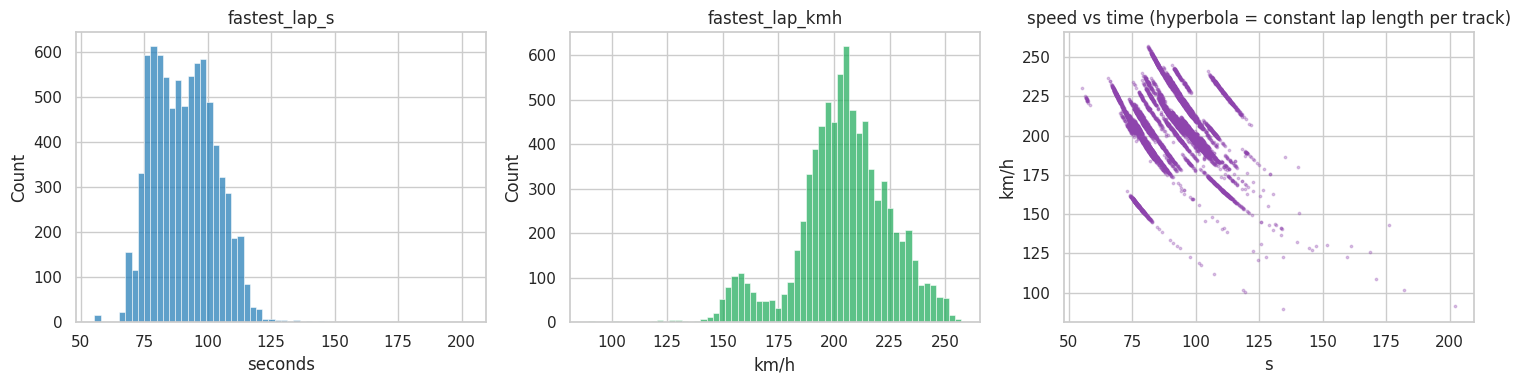

In [14]:
fl = res.dropna(subset=["fastest_lap_s", "fastest_lap_kmh"]).copy()
print(fl[["fastest_lap_s", "fastest_lap_kmh"]].describe().round(2))

# Physical consistency: speed * time = lap length, which should be ~constant *per circuit*.
races = raw["races"][["raceId","year","circuitId","name"]].astype({"raceId":int,"year":int,"circuitId":int})
fl = fl.merge(races, on="raceId")
fl["lap_len_km"] = fl.fastest_lap_kmh * fl.fastest_lap_s / 3600
cv = fl.groupby("circuitId").lap_len_km.agg(["median","std","count"]); cv["cv_%"] = 100*cv["std"]/cv["median"]
print("\nlap-length coefficient of variation across circuits (median %):", round(cv[cv['count']>20]['cv_%'].median(), 2))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(fl.fastest_lap_s, bins=60, ax=ax[0], color="#2980b9"); ax[0].set_title("fastest_lap_s"); ax[0].set_xlabel("seconds")
sns.histplot(fl.fastest_lap_kmh, bins=60, ax=ax[1], color="#27ae60"); ax[1].set_title("fastest_lap_kmh"); ax[1].set_xlabel("km/h")
ax[2].scatter(fl.fastest_lap_s, fl.fastest_lap_kmh, s=3, alpha=.3, color="#8e44ad")
ax[2].set_title("speed vs time (hyperbola = constant lap length per track)"); ax[2].set_xlabel("s"); ax[2].set_ylabel("km/h")
plt.tight_layout(); plt.show()

**Interpretation.** Time and speed are inversely related (the hyperbola), and the implied lap length is identical within each circuit (CV 0.0%, because the dataset's speed was derived from lap time and a fixed track length), so both conversions are consistent with each other. This confirms the parse, not the original timing accuracy.
Raw lap time is **not comparable across circuits** (Monaco ≈ 75 s, Spa ≈ 105 s) — if anyone ever turns this into a feature (it is post-race, so it should not be), it must be normalised per race. Here it is used for EDA and the audit only.

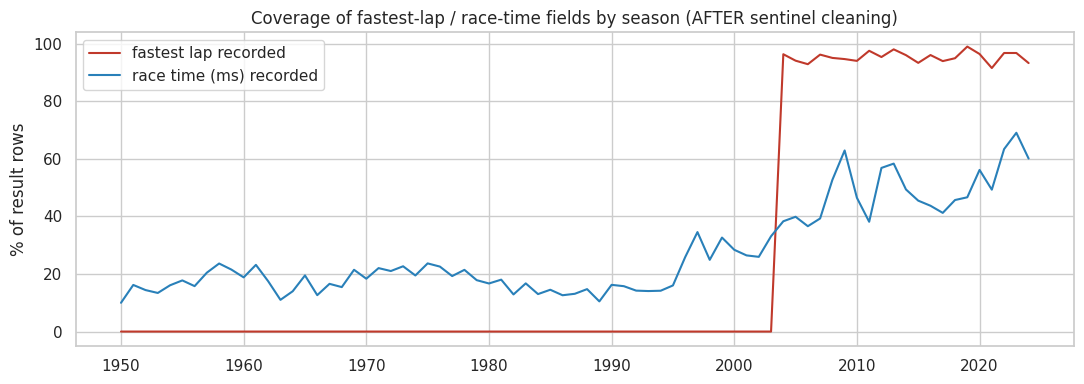

first season with any fastest-lap data: 2004


In [15]:
# Is the fastest-lap block missing randomly or structurally? -> coverage per season
cov = (res.merge(races[["raceId","year"]], on="raceId")
         .assign(has_fl=lambda d: d.fastest_lap_s.notna(), has_time=lambda d: d.race_time_s.notna())
         .groupby("year")[["has_fl", "has_time"]].mean() * 100)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(cov.index, cov.has_fl, label="fastest lap recorded", color="#c0392b")
ax.plot(cov.index, cov.has_time, label="race time (ms) recorded", color="#2980b9")
ax.set_ylabel("% of result rows"); ax.set_title("Coverage of fastest-lap / race-time fields by season (AFTER sentinel cleaning)"); ax.legend()
plt.tight_layout(); plt.show()
first_fl = cov.index[(cov.has_fl > 0)][0]; print("first season with any fastest-lap data:", first_fl)

**Interpretation.** The fastest-lap fields appear only from 2004 onward (0% in 2003) and are 92-99% complete every season afterwards, so their missingness is **structural (era-driven), not random** — they should not be imputed.
Because they are post-race anyway, this only matters for the audit and for the "historical coverage drift" limitation in the report.

### 3.2 Remaining consistency flags (documented, not silently 'fixed')

In [16]:
res["flag_fl_gt_laps"]   = res.fastestLap.notna() & (res.fastestLap > res.laps)
res["flag_posText_num_but_pos_nan"] = res.position.isna() & res.positionText.str.fullmatch(r"\d+", na=False)
res["grid_is_zero"] = res.grid.eq(0)
print("fastestLap > laps completed        :", int(res.flag_fl_gt_laps.sum()))
print("numeric positionText but position NaN:", int(res.flag_posText_num_but_pos_nan.sum()))
print("number (car no.) missing           :", int(res.number.isna().sum()))

fastestLap > laps completed        : 12
numeric positionText but position NaN: 2
number (car no.) missing           : 6


These are tiny (a dozen rows) and kept with a flag rather than dropped — dropping would change the grain. The cause of `fastestLap > laps` is not documented in the data, so I only flag it.

## 4. Key integrity (PK unique/non-null, FK reconcile)

In [17]:
def pk_check(df, cols, name):
    nn = int(df[cols].isna().any(axis=1).sum()); dup = int(df.duplicated(cols).sum())
    print(f"PK {name}({', '.join(cols)}): null={nn}, duplicates={dup} -> {'OK' if nn==dup==0 else 'PROBLEM'}")

def fk_check(child, col, parent, pcol, name):
    missing = ~child[col].astype(str).isin(parent[pcol].astype(str))
    print(f"FK {name}: {int(missing.sum())} orphan rows -> {'OK' if missing.sum()==0 else 'PROBLEM'}")

cres = raw["constructor_results"].replace(SENTINEL, np.nan).copy()
pk_check(res, ["resultId"], "results"); pk_check(status, ["statusId"], "status")
pk_check(cres, ["constructorResultsId"], "constructor_results")
fk_check(res, "raceId", raw["races"], "raceId", "results.raceId -> races")
fk_check(res, "driverId", raw["drivers"], "driverId", "results.driverId -> drivers")
fk_check(res, "constructorId", raw["constructors"], "constructorId", "results.constructorId -> constructors")
fk_check(res, "statusId", status, "statusId", "results.statusId -> status")
fk_check(cres, "raceId", raw["races"], "raceId", "constructor_results.raceId -> races")
fk_check(cres, "constructorId", raw["constructors"], "constructorId", "constructor_results.constructorId -> constructors")

print()
d = res[res.duplicated(["raceId","driverId"], keep=False)]
print("Natural key (raceId, driverId) duplicated rows:", len(d), "| extra rows to resolve:", int(res.duplicated(["raceId","driverId"]).sum()))
print("years affected:", sorted(d.merge(races[['raceId','year']], on='raceId').year.unique()))
print("cons.-results natural key (raceId, constructorId) duplicates:", int(cres.duplicated(["raceId","constructorId"]).sum()))
print("constructor_results.status values:", cres.status.value_counts(dropna=False).to_dict())

PK results(resultId): null=0, duplicates=0 -> OK
PK status(statusId): null=0, duplicates=0 -> OK
PK constructor_results(constructorResultsId): null=0, duplicates=0 -> OK
FK results.raceId -> races: 0 orphan rows -> OK
FK results.driverId -> drivers: 0 orphan rows -> OK
FK results.constructorId -> constructors: 0 orphan rows -> OK
FK results.statusId -> status: 0 orphan rows -> OK
FK constructor_results.raceId -> races: 0 orphan rows -> OK
FK constructor_results.constructorId -> constructors: 0 orphan rows -> OK

Natural key (raceId, driverId) duplicated rows: 176 | extra rows to resolve: 91
years affected: [np.int64(1950), np.int64(1951), np.int64(1952), np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1964), np.int64(1978)]
cons.-results natural key (raceId, constructorId) duplicates: 0
constructor_results.status values: {nan: 12608, 'D': 17}


**Findings.** All primary keys are unique and non-null and every foreign key reconciles. The one grain problem is the **duplicate `(raceId, driverId)`** (91 extra rows, mostly 1950-1964 shared drives, plus 1978). That rule belongs to the modeling-table owner (brief, Objective 1); I only report the count and years here so it can be resolved with the sprint-weekend and qualifying joins in mind.
`constructor_results.status` is `\N` for ~99.9% of rows and `D` (disqualified) for 17 — it will be converted to a boolean `constructor_disqualified`.

In [18]:
cres["points"] = pd.to_numeric(cres["points"])
for c in ["constructorResultsId","raceId","constructorId"]: cres[c] = cres[c].astype(int)
cres["constructor_disqualified"] = cres["status"].eq("D")
cres = cres.drop(columns="status")
cres.dtypes

constructorResultsId          int64
raceId                        int64
constructorId                 int64
points                      float64
constructor_disqualified       bool
dtype: object

## 5. Special task — grouping the 139 `status` values (Data-Engineering Question 3)

**Question-3 definition (from the brief):** a mechanical retirement is a start that ended early because *a component of the car failed*. It **excludes** crashes, driver-caused failures, and regulation decisions.

**Design of the mapping** (every one of the 139 values is assigned manually; the code *asserts* full coverage):

| `status_group` | Meaning | Example values |
|---|---|---|
| `finished` | classified at the flag, lead lap | Finished |
| `lapped_finish` | reached the flag, laps down | +1 Lap … +49 Laps (regex) |
| `mechanical` | **component failure** | Engine, Gearbox, Hydraulics, Power Unit, Electrical … |
| `accident_collision` | contact / crash / damage from an incident | Accident, Collision, Spun off, Puncture, Front wing … |
| `driver_team_error` | driver or team caused, no failed component | Out of fuel, Handling, Stalled |
| `driver_medical` | driver ill/injured | Illness, Injury, Eye injury |
| `regulation` | steward / technical decision | Disqualified, Excluded, Underweight, Safety concerns |
| `did_not_start` | never took the start | Did not qualify, Did not prequalify, Withdrew, 107% Rule |
| `other_unknown` | cause genuinely not stated | Retired, Not classified, Fire, Fuel |

**Ambiguous values.** Some labels could go either way (e.g. `Puncture`: tyre failure or debris? `Front wing`: failure or contact? `Wheel`: wheel came off). I make a defensible default call, mark them `mech_ambiguous = True`, and expose three definitions so Q3 can show a **sensitivity analysis** instead of hiding the judgement:
* `is_mechanical_strict` — clear-cut failures only
* `is_mechanical` — **primary definition** (the mapping above)
* `is_mechanical_broad` — primary + every ambiguous value that could be a failure

In [19]:
M = "mechanical"; A = "accident_collision"; E = "driver_team_error"; Md = "driver_medical"
R = "regulation"; N = "did_not_start"; U = "other_unknown"

def grp(group, names): return {n: group for n in names}
MAP = {}
MAP.update(grp("finished", ["Finished"]))
MAP.update(grp(M, ["Engine","Gearbox","Suspension","Transmission","Electrical","Brakes","Clutch","Fuel system","Turbo",
    "Hydraulics","Overheating","Ignition","Oil leak","Throttle","Halfshaft","Oil pressure","Fuel pump","Differential",
    "Fuel leak","Steering","Radiator","Power Unit","Wheel bearing","Injection","Fuel pressure","Water leak","Alternator",
    "Exhaust","Chassis","Mechanical","Magneto","Driveshaft","Axle","Heat shield fire","Battery","Power loss","Distributor",
    "Oil pump","Oil pipe","Electronics","Vibrations","Wheel nut","Water pressure","Water pump","ERS","Supercharger",
    "Technical","Pneumatics","Spark plugs","Fuel pipe","Water pipe","Track rod","Oil line","Drivetrain","Engine misfire",
    "Engine fire","Crankshaft","CV joint","Brake duct","Cooling system","Launch control","Wheel rim",
    "Wheel","Seat","Driver Seat","Safety belt"]))
MAP.update(grp(A, ["Accident","Collision","Spun off","Collision damage","Fatal accident","Damage","Debris",
    "Puncture","Tyre puncture","Tyre","Broken wing","Front wing","Rear wing","Undertray"]))
MAP.update(grp(E, ["Out of fuel","Handling","Stalled","Refuelling","Fuel rig"]))
MAP.update(grp(Md, ["Physical","Injury","Injured","Driver unwell","Illness","Eye injury"]))
MAP.update(grp(R, ["Disqualified","Excluded","Underweight","Safety","Safety concerns"]))
MAP.update(grp(N, ["Did not qualify","Did not prequalify","Withdrew","107% Rule"]))
MAP.update(grp(U, ["Retired","Not classified","Not restarted","Fire","Fuel"]))

# Values that are genuinely arguable -> flagged for the sensitivity analysis
AMBIG = {"Wheel","Seat","Driver Seat","Safety belt",                       # in 'mechanical' but arguable
         "Puncture","Tyre puncture","Tyre","Broken wing","Front wing","Rear wing","Undertray",   # contact vs failure
         "Handling","Refuelling","Fuel rig","Fire","Fuel","Stalled"}        # outside 'mechanical' but could be failures

def classify(s):
    if s in MAP: return MAP[s]
    if re.fullmatch(r"\+\d+ Laps?", s): return "lapped_finish"
    return None

status["status_group"] = status["status"].map(classify)
unmapped = status[status.status_group.isna()]
assert unmapped.empty, f"UNMAPPED statuses: {unmapped.status.tolist()}"
bad_ambig = AMBIG - set(status.status); assert not bad_ambig, f"typo in AMBIG: {bad_ambig}"
bad_map = set(MAP) - set(status.status); assert not bad_map, f"typo in MAP: {bad_map}"

status["mech_ambiguous"]       = status.status.isin(AMBIG)
status["is_mechanical"]        = status.status_group.eq(M)
status["is_mechanical_strict"] = status.is_mechanical & ~status.mech_ambiguous
status["is_mechanical_broad"]  = status.is_mechanical | status.mech_ambiguous
status["is_race_start"]        = ~status.status_group.eq(N)
status["is_retirement"]        = status.is_race_start & ~status.status_group.isin(["finished","lapped_finish","regulation"])

print(f"all {len(status)} statuses mapped | groups:")
display(status.groupby("status_group").agg(n_status_values=("status","size"),
        mech_ambiguous=("mech_ambiguous","sum")).sort_values("n_status_values", ascending=False))

all 139 statuses mapped | groups:


,n_status_values,mech_ambiguous
status_group,,
mechanical,66,4
lapped_finish,33,0
accident_collision,14,7
driver_medical,6,0
driver_team_error,5,4
other_unknown,5,2
regulation,5,0
did_not_start,4,0
finished,1,0


### 5.1 Validate the mapping against independent evidence
A manual mapping is only trustworthy if it agrees with *other* columns it was not built from. `positionText` (`R` = retired, `D` = disqualified, `F` = failed to qualify, `W` = withdrawn) gives that check.

positionText,D,E,F,N,R,W,numeric
status_group,,,,,,,
accident_collision,2,0,0,0,2683,35,184
did_not_start,0,0,1365,0,17,228,3
driver_medical,0,0,3,0,44,17,1
driver_team_error,0,0,0,0,80,0,79
finished,0,0,0,0,0,0,7674
lapped_finish,0,0,0,19,5,0,7463
mechanical,2,0,0,0,5968,50,390
other_unknown,0,0,0,171,100,2,14
regulation,147,9,0,0,0,4,0


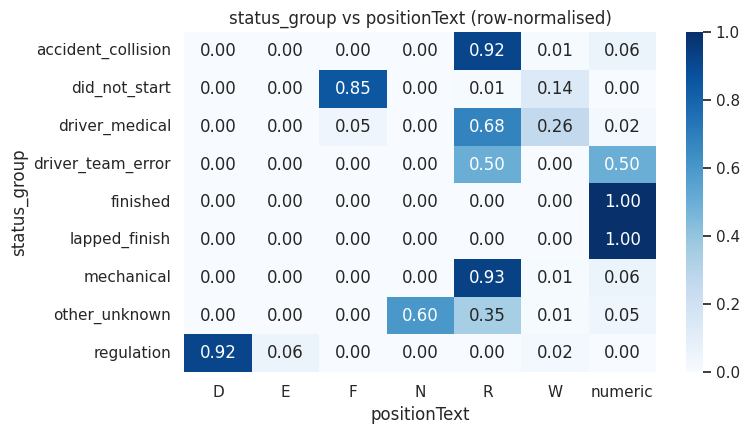

In [20]:
chk = res.merge(status[["statusId","status","status_group"]], on="statusId")
xt = pd.crosstab(chk.status_group, chk.positionText.where(chk.positionText.isin(list("RDFWNE")), "numeric"))
display(xt)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(xt.div(xt.sum(axis=1), axis=0).round(2), annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("status_group vs positionText (row-normalised)"); plt.tight_layout(); plt.show()

**Interpretation.** `mechanical`, `accident_collision` and `driver_team_error` rows are almost entirely `R` (retired) or classified-by-distance numeric positions; `did_not_start` maps to `F`/`W`; `regulation` maps to `D`/`E`. The groups line up with the independent column, which supports the mapping. The numeric column for retirements is expected: drivers who completed 90% of the distance are classified despite stopping.

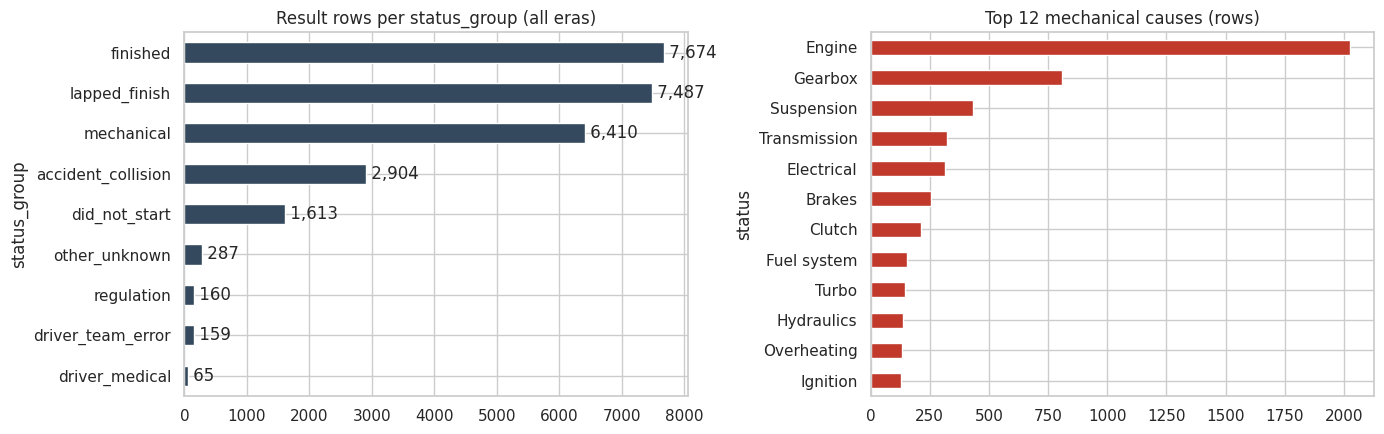

In [21]:
cnt = chk.status_group.value_counts()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
cnt.sort_values().plot.barh(ax=ax[0], color="#34495e"); ax[0].set_title("Result rows per status_group (all eras)")
for y, v in enumerate(cnt.sort_values()): ax[0].text(v, y, f" {v:,}", va="center")
top = (chk[chk.status_group.eq(M)].status.value_counts().head(12)).sort_values()
top.plot.barh(ax=ax[1], color="#c0392b"); ax[1].set_title("Top 12 mechanical causes (rows)")
plt.tight_layout(); plt.show()

### 5.2 Sanity preview for Question 3 (not the final answer)
Mechanical-retirement rate = mechanical retirements ÷ **race starts** (`did_not_start` excluded from the denominator, since a DNQ never raced). Reliability should improve over time and the three definitions should move together — if they diverge sharply the ambiguity matters.

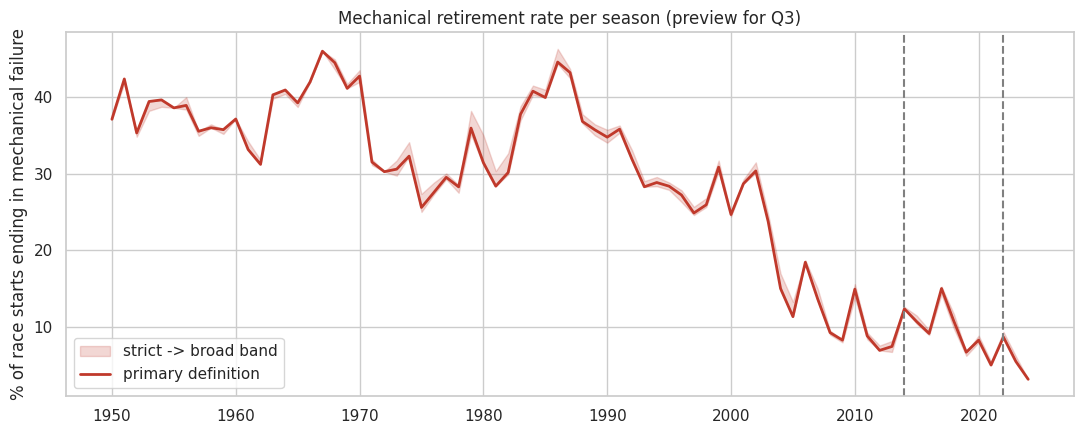

2014-2021: starts= 3258 | strict 9.30% | primary 9.67% | broad 10.13%
2022-2024: starts= 1354 | strict 5.69% | primary 5.69% | broad 6.13%


In [22]:
q = (res.merge(status[["statusId","status_group","is_mechanical","is_mechanical_strict","is_mechanical_broad","is_race_start"]], on="statusId")
        .merge(races[["raceId","year"]], on="raceId"))
q = q[q.is_race_start]
by = q.groupby("year")[["is_mechanical_strict","is_mechanical","is_mechanical_broad"]].mean() * 100
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(by.index, by.is_mechanical_strict, by.is_mechanical_broad, alpha=.2, color="#c0392b", label="strict -> broad band")
ax.plot(by.index, by.is_mechanical, color="#c0392b", lw=2, label="primary definition")
for x in (2014, 2022): ax.axvline(x, ls="--", color="gray")
ax.set_ylabel("% of race starts ending in mechanical failure"); ax.set_title("Mechanical retirement rate per season (preview for Q3)")
ax.legend(); plt.tight_layout(); plt.show()
for a, b in [(2014, 2021), (2022, 2024)]:
    s = q[q.year.between(a, b)]
    print(f"{a}-{b}: starts={len(s):5d} | strict {100*s.is_mechanical_strict.mean():.2f}% | primary {100*s.is_mechanical.mean():.2f}% | broad {100*s.is_mechanical_broad.mean():.2f}%")

**Interpretation.** The rate sits around 30-40% of starts from the 1950s to the 1980s, then falls to ~18% in the 2000s, ~10% in the 2010s and ~6% in the 2020s, matching the brief's note on early-F1 reliability. For Q3 specifically: 9.7% (2014-2021) vs 5.7% (2022-2024) overall on the primary definition. The strict/primary/broad band is narrow in the 2014+ window, so the ambiguous labels barely change the Q3 ranking in the eras that matter — but the report should still state the band.

## 6. Final cleaned tables + AFTER-cleaning audit

In [23]:
out = res.merge(status[["statusId","status","status_group","is_mechanical","is_mechanical_strict",
                        "is_mechanical_broad","mech_ambiguous","is_race_start","is_retirement"]], on="statusId", how="left")
assert len(out) == len(res), "join must not change grain"
assert out["resultId"].is_unique

# after-cleaning missingness (true NaN) -- compare with the BEFORE plot in section 1
after = out[["position","time","milliseconds","fastestLap","rank","fastestLapTime","fastestLapSpeed",
             "fastest_lap_s","race_time_s","gap_to_winner_s"]].isna().mean().mul(100).round(2)
before = rep_res.pct.reindex(["position","time","milliseconds","fastestLap","rank","fastestLapTime","fastestLapSpeed"])
cmp = pd.DataFrame({"before_%\\N": before, "after_%NaN": after}).fillna("(new col)")
display(cmp)
print("literal \\N left anywhere:", int((out.astype(str) == SENTINEL).any().any()))
print("rank==0 left:", int(out["rank"].eq(0).sum()))

,before_%\N,after_%NaN
fastestLap,69.16,69.16
fastestLapSpeed,69.16,69.16
fastestLapTime,69.16,69.16
fastest_lap_s,(new col),69.16
gap_to_winner_s,(new col),71.30
milliseconds,71.3,71.30
position,40.93,40.93
race_time_s,(new col),71.30
rank,68.2,69.16
time,71.3,71.30


literal \N left anywhere: 0
rank==0 left: 0


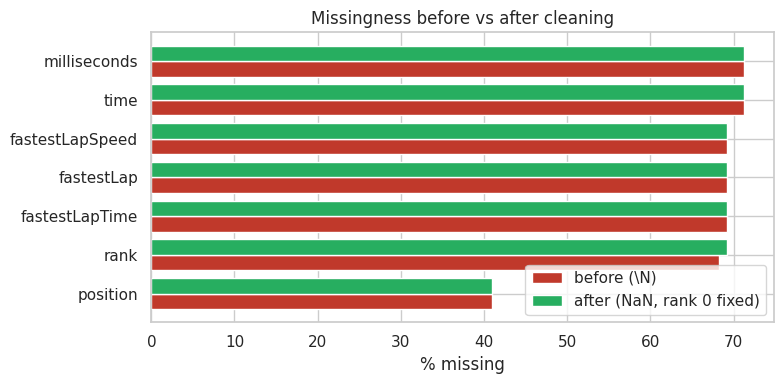

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
b = before.sort_values(); a = after.reindex(b.index)
y = np.arange(len(b)); ax.barh(y - .2, b.values, .4, label="before (\\N)", color="#c0392b")
ax.barh(y + .2, a.values, .4, label="after (NaN, rank 0 fixed)", color="#27ae60")
ax.set_yticks(y); ax.set_yticklabels(b.index); ax.set_xlabel("% missing"); ax.legend()
ax.set_title("Missingness before vs after cleaning"); plt.tight_layout(); plt.show()

**Effect of cleaning.** The % missing is intentionally almost unchanged: the sentinel was *encoded* missingness, so the real change is type, not volume. Cleaning turned strings like `"1:27.452"` into numbers, `\N` into true `NaN`, `rank = 0` into `NaN` (the only place the count moves: `rank` gains the 258 ghost zeros as missing), and added typed, validated helper columns.

## 7. Leakage audit of my three tables (pre-race cutoff = after qualifying)

| Column(s) | Pre-race? | Verdict |
|---|---|---|
| `raceId`, `driverId`, `constructorId`, `number` | yes | identifiers / usable |
| `grid` | yes (set before the start) | **allowed feature** (0 = no slot / pit lane, see 2.2) |
| `position`, `positionText`, `positionOrder`, `points`, `laps`, `time`, `milliseconds`, `fastest*`, `rank`, `statusId` + everything derived from them (`status_group`, `is_mechanical*`) | **no — outcomes** | **forbidden for current-race features**; usable only as *history* of earlier races (shifted) |
| `constructor_results.points`, `constructor_disqualified` | **no — current-race outcome** | forbidden for the same race; usable only via shifted constructor-form |

`status_group` is only for Question 3 and for building *lagged* reliability features (e.g. a constructor's mechanical-failure rate over its previous N races) — never for the race being predicted.

In [26]:
keep_first = ["resultId","raceId","driverId","constructorId","number","grid","grid_is_zero","position","positionText",
              "positionOrder","points","laps","time","gap_to_winner_s","milliseconds","race_time_s","fastestLap","rank",
              "fastestLapTime","fastest_lap_s","fastestLapSpeed","fastest_lap_kmh","statusId","status","status_group",
              "is_mechanical","is_mechanical_strict","is_mechanical_broad","mech_ambiguous","is_race_start","is_retirement",
              "flag_fl_gt_laps","flag_posText_num_but_pos_nan"]
out[keep_first].to_csv(f"{OUT_DIR}/results_clean.csv", index=False)
status.to_csv(f"{OUT_DIR}/status_mapping.csv", index=False)
cres.to_csv(f"{OUT_DIR}/constructor_results_clean.csv", index=False)
print("written:", [f for f in os.listdir(OUT_DIR) if f.endswith('.csv')])

written: ['constructor_results_clean.csv', 'results_clean.csv', 'status_mapping.csv']
